# Baseline Models: Department and Seniority from Job Titles

This notebook is only about baseline modeling and evaluation.
EDA and dataset exploration are documented in main eda.

We evaluate two approaches.
First, a simple rule based approach.
Second, TF IDF plus Logistic Regression.

For each approach we evaluate Department and Seniority.
For each task we evaluate on a held out CSV test split and then on the annotated JSON current job titles.
For Seniority, JSON evaluation is strict and drops labels that are not present in the training CSV label set.


## 1. Setup


In [73]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

RANDOM_STATE = 0
TEST_SIZE = 0.2


## 2. Data paths


In [74]:
cwd = Path.cwd()

if (cwd / "Data" / "Original Data").exists():
    DATA_DIR = cwd / "Data" / "Original Data"
elif (cwd.parent / "Data" / "Original Data").exists():
    DATA_DIR = cwd.parent / "Data" / "Original Data"
else:
    raise FileNotFoundError("Could not find data directory (expected Data/Original Data).")

paths = {
    "department_csv": DATA_DIR / "department-v2.csv",
    "seniority_csv": DATA_DIR / "seniority-v2.csv",
    "json_annotated": DATA_DIR / "linkedin-cvs-annotated.json",
    "json_unannotated": DATA_DIR / "linkedin_cvs_not_annotated",
}
paths

{'department_csv': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/department-v2.csv'),
 'seniority_csv': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/seniority-v2.csv'),
 'json_annotated': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/linkedin-cvs-annotated.json'),
 'json_unannotated': PosixPath('/home/dom/Code/githuub push/PracticalDataScience/Data/Original Data/linkedin_cvs_not_annotated')}

## 3. Load labeled CSVs


In [75]:
dept_df = pd.read_csv(paths["department_csv"])
sen_df  = pd.read_csv(paths["seniority_csv"])


for df in (dept_df, sen_df):
    unnamed = [c for c in df.columns if str(c).lower().startswith("unnamed")]
    if unnamed:
        df.drop(columns=unnamed, inplace=True)

for name, df in [("department", dept_df), ("seniority", sen_df)]:
    if not {"text", "label"}.issubset(df.columns):
        raise ValueError(f"{name} CSV must contain columns: text, label")

dept_df = dept_df[["text", "label"]].dropna().copy()
sen_df = sen_df[["text", "label"]].dropna().copy()

dept_df["text"] = dept_df["text"].astype(str)
dept_df["label"] = dept_df["label"].astype(str)

sen_df["text"] = sen_df["text"].astype(str)
sen_df["label"] = sen_df["label"].astype(str)

print({
    "department_rows": int(len(dept_df)),
    "seniority_rows": int(len(sen_df)),
    "department_labels": int(dept_df["label"].nunique()),
    "seniority_labels": int(sen_df["label"].nunique()),
})
print(dept_df.head(3).to_string(index=False))
print(sen_df.head(3).to_string(index=False))

{'department_rows': 10145, 'seniority_rows': 9428, 'department_labels': 11, 'seniority_labels': 5}
                           text              label
Adjoint directeur communication          Marketing
  Advisor Strategy and Projects Project Management
            Beratung & Projekte Project Management
                             text  label
                          Analyst Junior
               Analyste financier Junior
Anwendungstechnischer Mitarbeiter Junior


## 4. Train test splits


In [76]:
dept_labels = sorted(dept_df["label"].unique())
sen_labels = sorted(sen_df["label"].unique())

dept_train, dept_test = train_test_split(
    dept_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=dept_df["label"],
)

sen_train, sen_test = train_test_split(
    sen_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=sen_df["label"],
)

print({
    "dept_train": int(len(dept_train)),
    "dept_test": int(len(dept_test)),
    "sen_train": int(len(sen_train)),
    "sen_test": int(len(sen_test)),
})


{'dept_train': 8116, 'dept_test': 2029, 'sen_train': 7542, 'sen_test': 1886}


## 5. Load JSON evaluation data


In [77]:
with open(paths["json_annotated"], "r", encoding="utf-8") as f:
    cvs = json.load(f)

rows = []
for cv_id, jobs in enumerate(cvs):
    for job_index, job in enumerate(jobs):
        rows.append({"cv_id": cv_id, "job_index": job_index, **job})

jobs_df = pd.DataFrame(rows)

active_jobs = jobs_df[jobs_df["status"] == "ACTIVE"].copy()
active_jobs["start_dt"] = pd.to_datetime(active_jobs.get("startDate"), errors="coerce")

current_jobs = (
    active_jobs
    .sort_values(["cv_id", "start_dt", "job_index"])
    .groupby("cv_id", as_index=False)
    .tail(1)
    .drop(columns=["start_dt"], errors="ignore")
)

df_eval = (
    current_jobs
    .rename(columns={"position": "text", "department": "dept", "seniority": "sen"})
    [["cv_id", "text", "dept", "sen"]]
    .copy()
)

df_eval["text"] = df_eval["text"].astype(str)

dept_eval_json = df_eval[["text", "dept"]].dropna().rename(columns={"dept": "label"}).copy()
dept_eval_json["label"] = dept_eval_json["label"].astype(str)

sen_eval_json = df_eval[["text", "sen"]].dropna().rename(columns={"sen": "label"}).copy()
sen_eval_json["label"] = sen_eval_json["label"].astype(str)

unknown_sen_labels = sorted(set(sen_eval_json["label"].unique()) - set(sen_labels))
sen_eval_json_strict = sen_eval_json[sen_eval_json["label"].isin(sen_labels)].copy()

print({
    "cvs_total": int(len(cvs)),
    "jobs_total": int(len(jobs_df)),
    "current_jobs": int(len(df_eval)),
    "department_eval_rows": int(len(dept_eval_json)),
    "seniority_eval_rows": int(len(sen_eval_json)),
    "seniority_eval_strict_rows": int(len(sen_eval_json_strict)),
})

print({"unknown_seniority_labels_in_json": unknown_sen_labels})
print(df_eval.head(5).to_string(index=False))

{'cvs_total': 609, 'jobs_total': 2638, 'current_jobs': 478, 'department_eval_rows': 478, 'seniority_eval_rows': 478, 'seniority_eval_strict_rows': 313}
{'unknown_seniority_labels_in_json': ['Professional']}
 cv_id                           text                   dept          sen
     0                      Prokurist                  Other   Management
     1            Solutions Architect Information Technology Professional
     2        Medizintechnik Beratung             Consulting Professional
     3 Director expansión de negocio.   Business Development     Director
     4       APL-ansvarig, samordning         Administrative         Lead


## 6. Baseline 1: Rule based

This baseline uses exact title matches first.
If no exact match exists, it uses token overlap between the title and label specific token sets.


### 6.0 Rule based setup


In [78]:
stopwords = {
    "and", "or", "the", "a", "an", "of", "for", "to", "in", "on", "with", "at",
    "und", "oder", "der", "die", "das", "ein", "eine", "im", "am", "mit", "bei",
}

pattern = re.compile(r"[a-zA-Zäöüßéèàçêîôùñ]+")


### 6.1 Department


#### 6.1.1 Build rule based resources from dept_train


In [79]:
dept_train_norm = dept_train["text"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

dept_exact_map = {}
for t_norm, lab in zip(dept_train_norm.tolist(), dept_train["label"].tolist()):
    if t_norm and t_norm not in dept_exact_map:
        dept_exact_map[t_norm] = str(lab)

dept_label_tokens = {}
for lab in dept_labels:
    toks = set()
    titles = dept_train.loc[dept_train["label"] == lab, "text"].tolist()
    for title in titles:
        for tok in pattern.findall(str(title).lower()):
            if tok not in stopwords:
                toks.add(tok)
    dept_label_tokens[str(lab)] = toks

dept_default_label = str(dept_train["label"].value_counts().idxmax())

print({"dept_default_label": dept_default_label})


{'dept_default_label': 'Marketing'}


#### 6.1.2 CSV test evaluation


In [80]:
dept_pred_rule_csv = []
for title in dept_test["text"].tolist():
    t_norm = str(title).lower().strip()
    t_norm = re.sub(r"\s+", " ", t_norm)

    if t_norm in dept_exact_map:
        dept_pred_rule_csv.append(dept_exact_map[t_norm])
        continue

    title_tokens = set(tok for tok in pattern.findall(str(title).lower()) if tok not in stopwords)

    best_label = dept_default_label
    best_score = -1
    for lab in dept_labels:
        score = len(title_tokens & dept_label_tokens[str(lab)])
        if score > best_score:
            best_score = score
            best_label = str(lab)

    dept_pred_rule_csv.append(best_label)

dept_y_true_csv = dept_test["label"].astype(str)

dept_acc_rule_csv = float(accuracy_score(dept_y_true_csv, dept_pred_rule_csv))
dept_macro_f1_rule_csv = float(f1_score(dept_y_true_csv, dept_pred_rule_csv, average="macro"))

print({"n": int(len(dept_y_true_csv)), "accuracy": dept_acc_rule_csv, "macro_f1": dept_macro_f1_rule_csv})

print(classification_report(dept_y_true_csv, dept_pred_rule_csv, zero_division=0))
report = classification_report(dept_y_true_csv, dept_pred_rule_csv, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[dept_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 2029, 'accuracy': 0.350418925579103, 'macro_f1': 0.2595361112851501}
                        precision    recall  f1-score   support

        Administrative       0.34      0.59      0.43        17
  Business Development       0.29      0.80      0.42       124
            Consulting       0.35      0.18      0.24        33
      Customer Support       0.25      0.14      0.18         7
       Human Resources       0.06      0.50      0.11         6
Information Technology       0.09      0.24      0.13       261
             Marketing       0.56      0.49      0.52       859
                 Other       0.00      0.00      0.00         8
    Project Management       0.00      0.00      0.00        40
            Purchasing       1.00      0.38      0.55         8
                 Sales       0.67      0.17      0.27       666

              accuracy                           0.35      2029
             macro avg       0.33      0.32      0.26      2029
          weighted avg     

#### 6.1.3 Confusion matrix and dominant confusions


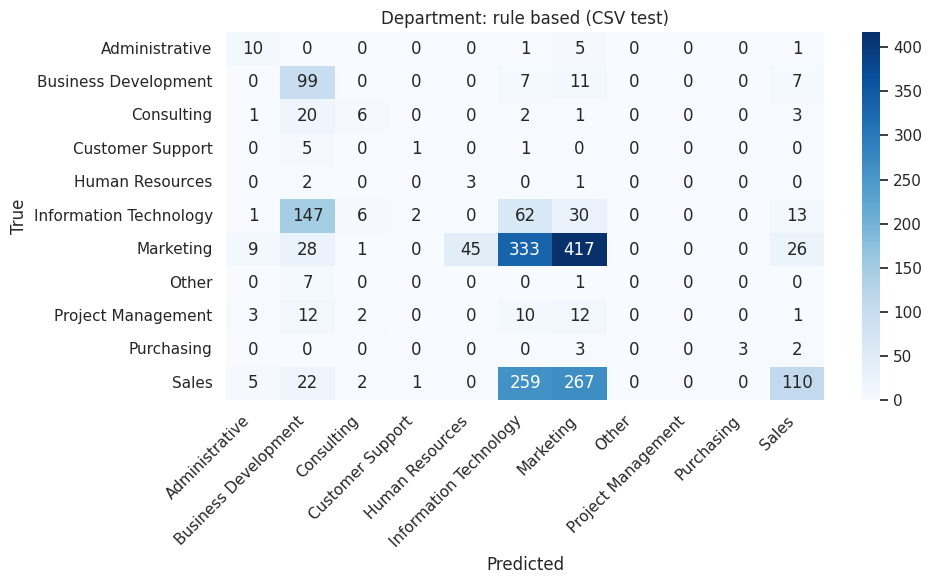

                  true                   pred  count
             Marketing Information Technology    333
                 Sales              Marketing    267
                 Sales Information Technology    259
Information Technology   Business Development    147
             Marketing        Human Resources     45
Information Technology              Marketing     30
             Marketing   Business Development     28
             Marketing                  Sales     26
                 Sales   Business Development     22
            Consulting   Business Development     20


In [81]:
cm = confusion_matrix(dept_y_true_csv, dept_pred_rule_csv, labels=dept_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dept_labels, yticklabels=dept_labels)
ax.set_title("Department: rule based (CSV test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(dept_labels):
    for j, p_lab in enumerate(dept_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

This rule based baseline is mostly driven by surface tokens.
The per class precision and recall table shows that some labels are hard to separate with simple token overlap.
The confusion matrix and the top confusions indicate that many titles use shared vocabulary across departments, so the model often assigns a plausible but wrong related label.
This is a useful baseline because it is transparent, but it sets a low performance floor for the Department task.


#### 6.1.4 Build rule based resources from full dept_df


In [82]:
dept_full_norm = dept_df["text"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

dept_exact_map_full = {}
for t_norm, lab in zip(dept_full_norm.tolist(), dept_df["label"].tolist()):
    if t_norm and t_norm not in dept_exact_map_full:
        dept_exact_map_full[t_norm] = str(lab)

dept_label_tokens_full = {}
for lab in dept_labels:
    toks = set()
    titles = dept_df.loc[dept_df["label"] == lab, "text"].tolist()
    for title in titles:
        for tok in pattern.findall(str(title).lower()):
            if tok not in stopwords:
                toks.add(tok)
    dept_label_tokens_full[str(lab)] = toks

dept_default_label_full = str(dept_df["label"].value_counts().idxmax())

print({"dept_default_label_full": dept_default_label_full})


{'dept_default_label_full': 'Marketing'}


#### 6.1.5 JSON evaluation


In [83]:
dept_pred_rule_json = []
for title in dept_eval_json["text"].tolist():
    t_norm = str(title).lower().strip()
    t_norm = re.sub(r"\s+", " ", t_norm)

    if t_norm in dept_exact_map_full:
        dept_pred_rule_json.append(dept_exact_map_full[t_norm])
        continue

    title_tokens = set(tok for tok in pattern.findall(str(title).lower()) if tok not in stopwords)

    best_label = dept_default_label_full
    best_score = -1
    for lab in dept_labels:
        score = len(title_tokens & dept_label_tokens_full[str(lab)])
        if score > best_score:
            best_score = score
            best_label = str(lab)

    dept_pred_rule_json.append(best_label)

dept_y_true_json = dept_eval_json["label"].astype(str)

dept_acc_rule_json = float(accuracy_score(dept_y_true_json, dept_pred_rule_json))
dept_macro_f1_rule_json = float(f1_score(dept_y_true_json, dept_pred_rule_json, average="macro"))

print({"n": int(len(dept_y_true_json)), "accuracy": dept_acc_rule_json, "macro_f1": dept_macro_f1_rule_json})

print(classification_report(dept_y_true_json, dept_pred_rule_json, zero_division=0))
report = classification_report(dept_y_true_json, dept_pred_rule_json, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[dept_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 478, 'accuracy': 0.14225941422594143, 'macro_f1': 0.1908801098456271}
                        precision    recall  f1-score   support

        Administrative       0.05      0.44      0.08         9
  Business Development       0.08      0.76      0.14        17
            Consulting       0.36      0.14      0.20        29
      Customer Support       0.00      0.00      0.00         6
       Human Resources       0.40      0.13      0.20        15
Information Technology       0.15      0.17      0.16        54
             Marketing       0.07      0.32      0.11        19
                 Other       0.00      0.00      0.00       250
    Project Management       0.91      0.32      0.48        31
            Purchasing       1.00      0.17      0.29        12
                 Sales       0.40      0.50      0.44        36

              accuracy                           0.14       478
             macro avg       0.31      0.27      0.19       478
          weighted avg    

#### 6.1.6 Confusion matrix and dominant confusions


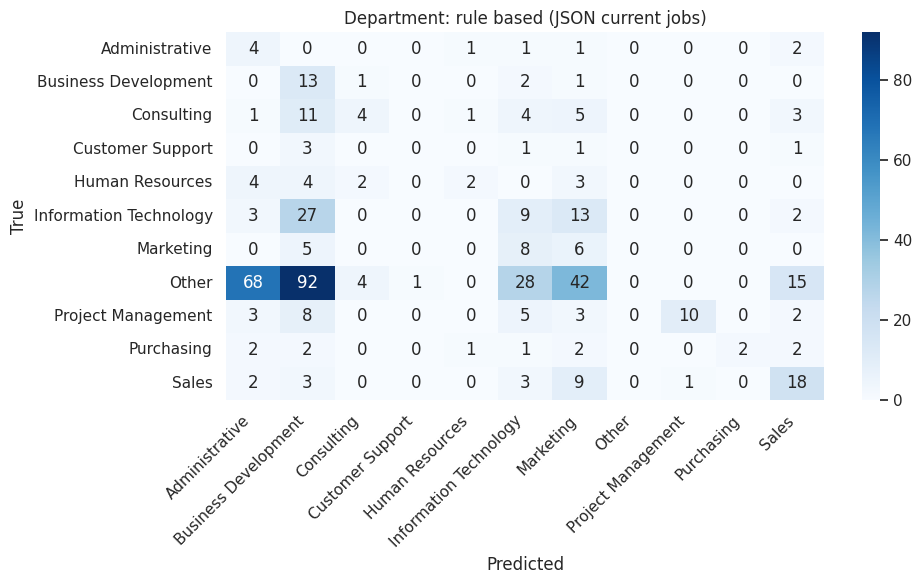

                  true                   pred  count
                 Other   Business Development     92
                 Other         Administrative     68
                 Other              Marketing     42
                 Other Information Technology     28
Information Technology   Business Development     27
                 Other                  Sales     15
Information Technology              Marketing     13
            Consulting   Business Development     11
                 Sales              Marketing      9
    Project Management   Business Development      8


In [84]:
cm = confusion_matrix(dept_y_true_json, dept_pred_rule_json, labels=dept_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dept_labels, yticklabels=dept_labels)
ax.set_title("Department: rule based (JSON current jobs)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(dept_labels):
    for j, p_lab in enumerate(dept_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

Performance drops on JSON current jobs compared to the CSV test split.
This suggests a distribution shift between the curated labeled CSV titles and real world current job titles.
A recurring pattern in the confusion matrix is that true Other titles are over assigned to specific departments.
This supports the key point that Department generalization to real CV titles is the main challenge for this project.


### 6.2 Seniority


#### 6.2.1 Build rule based resources from sen_train


In [85]:
sen_train_norm = sen_train["text"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

sen_exact_map = {}
for t_norm, lab in zip(sen_train_norm.tolist(), sen_train["label"].tolist()):
    if t_norm and t_norm not in sen_exact_map:
        sen_exact_map[t_norm] = str(lab)

sen_label_tokens = {}
for lab in sen_labels:
    toks = set()
    titles = sen_train.loc[sen_train["label"] == lab, "text"].tolist()
    for title in titles:
        for tok in pattern.findall(str(title).lower()):
            if tok not in stopwords:
                toks.add(tok)
    sen_label_tokens[str(lab)] = toks

sen_default_label = str(sen_train["label"].value_counts().idxmax())

print({"sen_default_label": sen_default_label})


{'sen_default_label': 'Senior'}


#### 6.2.2 CSV test evaluation


In [86]:
sen_pred_rule_csv = []
for title in sen_test["text"].tolist():
    t_norm = str(title).lower().strip()
    t_norm = re.sub(r"\s+", " ", t_norm)

    if t_norm in sen_exact_map:
        sen_pred_rule_csv.append(sen_exact_map[t_norm])
        continue

    title_tokens = set(tok for tok in pattern.findall(str(title).lower()) if tok not in stopwords)

    best_label = sen_default_label
    best_score = -1
    for lab in sen_labels:
        score = len(title_tokens & sen_label_tokens[str(lab)])
        if score > best_score:
            best_score = score
            best_label = str(lab)

    sen_pred_rule_csv.append(best_label)

sen_y_true_csv = sen_test["label"].astype(str)

sen_acc_rule_csv = float(accuracy_score(sen_y_true_csv, sen_pred_rule_csv))
sen_macro_f1_rule_csv = float(f1_score(sen_y_true_csv, sen_pred_rule_csv, average="macro"))

print({"n": int(len(sen_y_true_csv)), "accuracy": sen_acc_rule_csv, "macro_f1": sen_macro_f1_rule_csv})

print(classification_report(sen_y_true_csv, sen_pred_rule_csv, zero_division=0))
report = classification_report(sen_y_true_csv, sen_pred_rule_csv, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[sen_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 1886, 'accuracy': 0.3297985153764581, 'macro_f1': 0.32313777418940237}
              precision    recall  f1-score   support

    Director       0.15      0.80      0.26       197
      Junior       0.38      0.71      0.50        82
        Lead       0.59      0.44      0.50       709
  Management       0.37      0.12      0.18       151
      Senior       0.59      0.11      0.18       747

    accuracy                           0.33      1886
   macro avg       0.42      0.43      0.32      1886
weighted avg       0.52      0.33      0.32      1886

              precision    recall  f1-score      support
Director       0.152575  0.796954  0.256117   197.000000
Junior         0.381579  0.707317  0.495726    82.000000
Lead           0.593090  0.435825  0.502439   709.000000
Management     0.367347  0.119205  0.180000   151.000000
Senior         0.592593  0.107095  0.181406   747.000000
accuracy       0.329799  0.329799  0.329799     0.329799
macro avg      0.417437  0.433279  

#### 6.2.3 Confusion matrix and dominant confusions


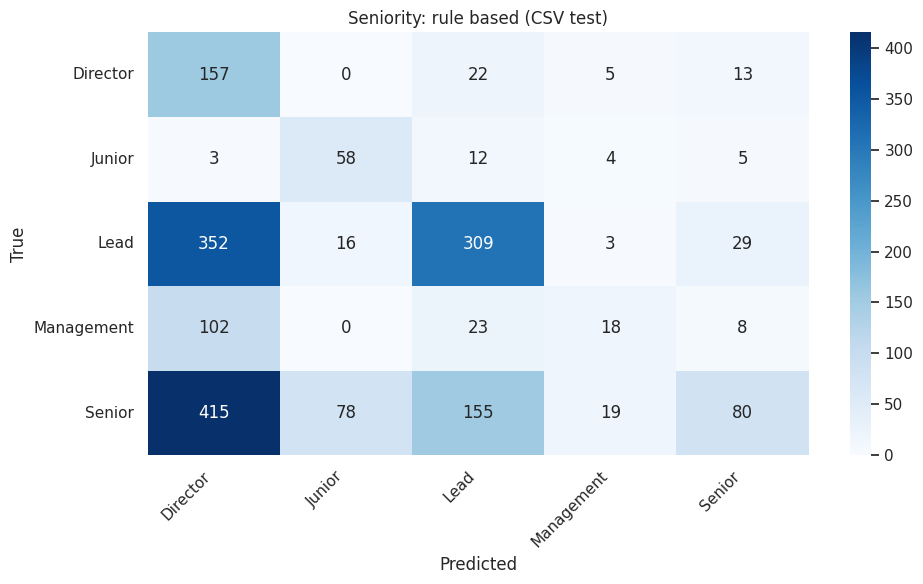

      true       pred  count
    Senior   Director    415
      Lead   Director    352
    Senior       Lead    155
Management   Director    102
    Senior     Junior     78
      Lead     Senior     29
Management       Lead     23
  Director       Lead     22
    Senior Management     19
      Lead     Junior     16


In [87]:
cm = confusion_matrix(sen_y_true_csv, sen_pred_rule_csv, labels=sen_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sen_labels, yticklabels=sen_labels)
ax.set_title("Seniority: rule based (CSV test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(sen_labels):
    for j, p_lab in enumerate(sen_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

Most errors happen between adjacent seniority levels.
This is visible in the confusion matrix where confusions concentrate between Senior, Lead, Management, and Director.
The per class precision and recall table often shows that minority or ambiguous levels have lower recall, while levels with strong title cues are easier.


#### 6.2.4 Build rule based resources from full sen_df


In [88]:
sen_full_norm = sen_df["text"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

sen_exact_map_full = {}
for t_norm, lab in zip(sen_full_norm.tolist(), sen_df["label"].tolist()):
    if t_norm and t_norm not in sen_exact_map_full:
        sen_exact_map_full[t_norm] = str(lab)

sen_label_tokens_full = {}
for lab in sen_labels:
    toks = set()
    titles = sen_df.loc[sen_df["label"] == lab, "text"].tolist()
    for title in titles:
        for tok in pattern.findall(str(title).lower()):
            if tok not in stopwords:
                toks.add(tok)
    sen_label_tokens_full[str(lab)] = toks

sen_default_label_full = str(sen_df["label"].value_counts().idxmax())

print({"sen_default_label_full": sen_default_label_full})


{'sen_default_label_full': 'Senior'}


#### 6.2.5 JSON evaluation (strict)

Seniority is evaluated in a strict label space.
Rows with seniority labels that are not present in the training CSV label set are excluded from evaluation.
We print the unknown labels and the number of remaining rows above.


In [89]:
sen_pred_rule_json = []
for title in sen_eval_json_strict["text"].tolist():
    t_norm = str(title).lower().strip()
    t_norm = re.sub(r"\s+", " ", t_norm)

    if t_norm in sen_exact_map_full:
        sen_pred_rule_json.append(sen_exact_map_full[t_norm])
        continue

    title_tokens = set(tok for tok in pattern.findall(str(title).lower()) if tok not in stopwords)

    best_label = sen_default_label_full
    best_score = -1
    for lab in sen_labels:
        score = len(title_tokens & sen_label_tokens_full[str(lab)])
        if score > best_score:
            best_score = score
            best_label = str(lab)

    sen_pred_rule_json.append(best_label)

sen_y_true_json = sen_eval_json_strict["label"].astype(str)

sen_acc_rule_json = float(accuracy_score(sen_y_true_json, sen_pred_rule_json))
sen_macro_f1_rule_json = float(f1_score(sen_y_true_json, sen_pred_rule_json, average="macro"))

print({"n": int(len(sen_y_true_json)), "accuracy": sen_acc_rule_json, "macro_f1": sen_macro_f1_rule_json})

print(classification_report(sen_y_true_json, sen_pred_rule_json, zero_division=0))
report = classification_report(sen_y_true_json, sen_pred_rule_json, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[sen_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 313, 'accuracy': 0.3961661341853035, 'macro_f1': 0.3970496898093781}
              precision    recall  f1-score   support

    Director       0.16      0.85      0.26        27
      Junior       0.40      0.44      0.42         9
        Lead       0.69      0.36      0.47       101
  Management       0.87      0.33      0.47       138
      Senior       0.31      0.42      0.36        38

    accuracy                           0.40       313
   macro avg       0.48      0.48      0.40       313
weighted avg       0.67      0.40      0.44       313

              precision    recall  f1-score     support
Director       0.156463  0.851852  0.264368   27.000000
Junior         0.400000  0.444444  0.421053    9.000000
Lead           0.692308  0.356436  0.470588  101.000000
Management     0.865385  0.326087  0.473684  138.000000
Senior         0.307692  0.421053  0.355556   38.000000
accuracy       0.396166  0.396166  0.396166    0.396166
macro avg      0.484369  0.479974  0.397050 

#### 6.2.6 Confusion matrix and dominant confusions


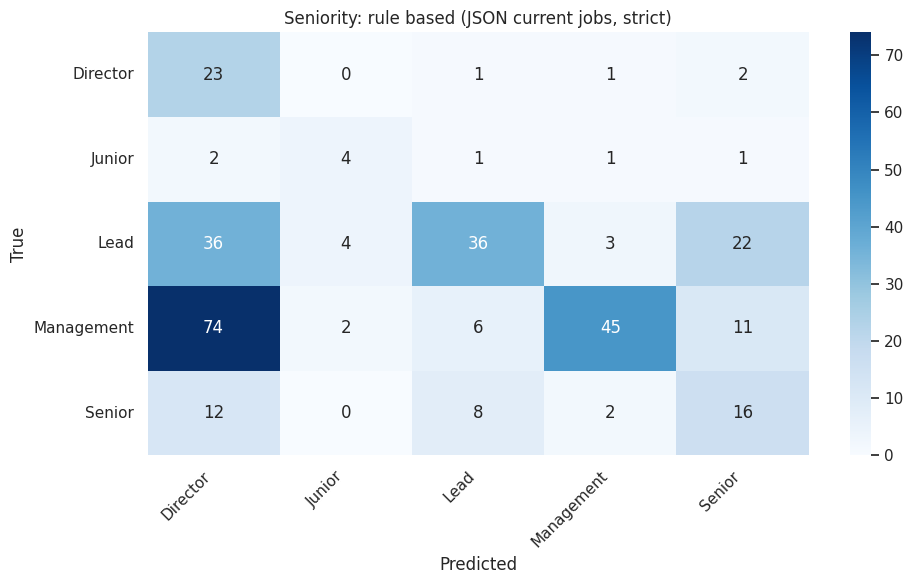

      true       pred  count
Management   Director     74
      Lead   Director     36
      Lead     Senior     22
    Senior   Director     12
Management     Senior     11
    Senior       Lead      8
Management       Lead      6
      Lead     Junior      4
      Lead Management      3
  Director     Senior      2


In [90]:
cm = confusion_matrix(sen_y_true_json, sen_pred_rule_json, labels=sen_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sen_labels, yticklabels=sen_labels)
ax.set_title("Seniority: rule based (JSON current jobs, strict)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(sen_labels):
    for j, p_lab in enumerate(sen_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

This is a strict evaluation.
Rows whose seniority label does not exist in the training CSV label set are excluded, so the evaluation set is smaller.
The confusion matrix still shows that errors are mostly between neighboring levels.
This matches the expectation that seniority boundaries are gradual and titles can be inconsistent across companies.


## 7. Baseline 2: TF IDF plus Logistic Regression

This baseline vectorizes titles with TF IDF and trains a Logistic Regression classifier.


### 7.1 Department


#### 7.1.1 Train TF IDF and Logistic Regression on dept_train


In [91]:
dept_vectorizer = TfidfVectorizer(lowercase=True, min_df=2, ngram_range=(1, 2))
X_dept_train = dept_vectorizer.fit_transform(dept_train["text"])

dept_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
_ = dept_clf.fit(X_dept_train, dept_train["label"])
print("dept_clf fitted")


dept_clf fitted


#### 7.1.2 CSV test evaluation


In [92]:
X_dept_test = dept_vectorizer.transform(dept_test["text"])
dept_pred_tfidf_csv = dept_clf.predict(X_dept_test)

dept_acc_tfidf_csv = float(accuracy_score(dept_y_true_csv, dept_pred_tfidf_csv))
dept_macro_f1_tfidf_csv = float(f1_score(dept_y_true_csv, dept_pred_tfidf_csv, average="macro"))

print({"n": int(len(dept_y_true_csv)), "accuracy": dept_acc_tfidf_csv, "macro_f1": dept_macro_f1_tfidf_csv})

print(classification_report(dept_y_true_csv, dept_pred_tfidf_csv, zero_division=0))
report = classification_report(dept_y_true_csv, dept_pred_tfidf_csv, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[dept_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 2029, 'accuracy': 0.9226219812715624, 'macro_f1': 0.8228298182089543}
                        precision    recall  f1-score   support

        Administrative       0.46      0.94      0.62        17
  Business Development       0.82      0.98      0.89       124
            Consulting       0.70      0.94      0.81        33
      Customer Support       0.78      1.00      0.88         7
       Human Resources       0.62      0.83      0.71         6
Information Technology       0.90      0.95      0.92       261
             Marketing       0.99      0.91      0.95       859
                 Other       0.53      1.00      0.70         8
    Project Management       0.63      0.95      0.76        40
            Purchasing       0.80      1.00      0.89         8
                 Sales       0.96      0.91      0.93       666

              accuracy                           0.92      2029
             macro avg       0.74      0.95      0.82      2029
          weighted avg    

#### 7.1.3 Confusion matrix and dominant confusions


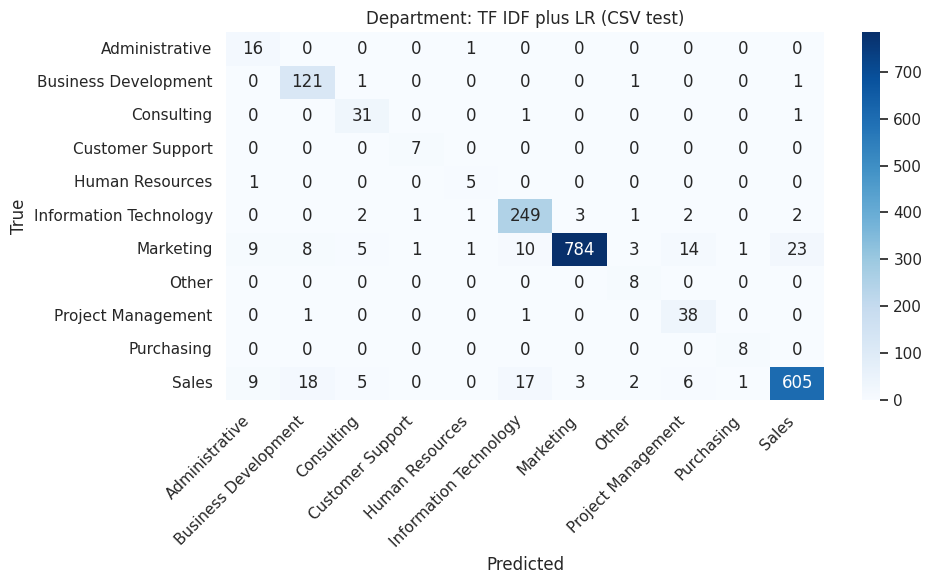

     true                   pred  count
Marketing                  Sales     23
    Sales   Business Development     18
    Sales Information Technology     17
Marketing     Project Management     14
Marketing Information Technology     10
Marketing         Administrative      9
    Sales         Administrative      9
Marketing   Business Development      8
    Sales     Project Management      6
    Sales             Consulting      5


In [93]:
cm = confusion_matrix(dept_y_true_csv, dept_pred_tfidf_csv, labels=dept_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dept_labels, yticklabels=dept_labels)
ax.set_title("Department: TF IDF plus LR (CSV test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(dept_labels):
    for j, p_lab in enumerate(dept_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

Compared to the rule based baseline, TF IDF plus Logistic Regression uses a learned weighting of tokens and n grams.
On the CSV test split this usually leads to much stronger precision and recall across most labels.
Remaining errors are concentrated between related departments with overlapping vocabulary.


#### 7.1.4 Train TF IDF and Logistic Regression on full dept_df


In [94]:
dept_vectorizer_full = TfidfVectorizer(lowercase=True, min_df=2, ngram_range=(1, 2))
X_dept_full = dept_vectorizer_full.fit_transform(dept_df["text"])

dept_clf_full = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
_ = dept_clf_full.fit(X_dept_full, dept_df["label"])
print("dept_clf_full fitted")


dept_clf_full fitted


#### 7.1.5 JSON evaluation


In [95]:
X_dept_json = dept_vectorizer_full.transform(dept_eval_json["text"])
dept_pred_tfidf_json = dept_clf_full.predict(X_dept_json)

dept_acc_tfidf_json = float(accuracy_score(dept_y_true_json, dept_pred_tfidf_json))
dept_macro_f1_tfidf_json = float(f1_score(dept_y_true_json, dept_pred_tfidf_json, average="macro"))

print({"n": int(len(dept_y_true_json)), "accuracy": dept_acc_tfidf_json, "macro_f1": dept_macro_f1_tfidf_json})

print(classification_report(dept_y_true_json, dept_pred_tfidf_json, zero_division=0))
report = classification_report(dept_y_true_json, dept_pred_tfidf_json, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[dept_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 478, 'accuracy': 0.2384937238493724, 'macro_f1': 0.3569458514285462}
                        precision    recall  f1-score   support

        Administrative       0.00      0.00      0.00         9
  Business Development       0.46      0.35      0.40        17
            Consulting       0.76      0.55      0.64        29
      Customer Support       1.00      0.17      0.29         6
       Human Resources       0.73      0.53      0.62        15
Information Technology       0.29      0.35      0.32        54
             Marketing       0.22      0.53      0.31        19
                 Other       0.00      0.00      0.00       250
    Project Management       0.33      0.58      0.42        31
            Purchasing       1.00      0.58      0.74        12
                 Sales       0.11      0.81      0.20        36

              accuracy                           0.24       478
             macro avg       0.45      0.40      0.36       478
          weighted avg     

#### 7.1.6 Confusion matrix and dominant confusions


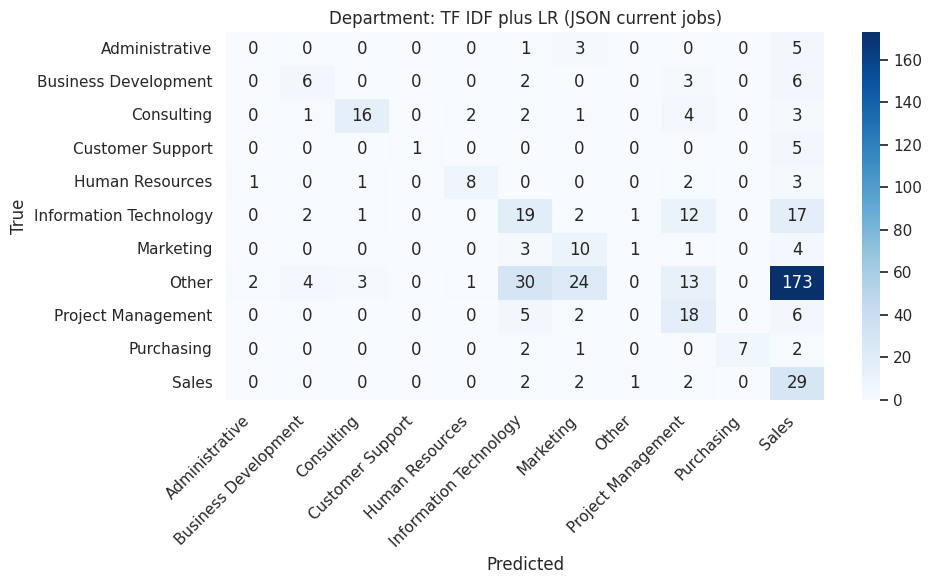

                  true                   pred  count
                 Other                  Sales    173
                 Other Information Technology     30
                 Other              Marketing     24
Information Technology                  Sales     17
                 Other     Project Management     13
Information Technology     Project Management     12
    Project Management                  Sales      6
  Business Development                  Sales      6
    Project Management Information Technology      5
      Customer Support                  Sales      5


In [96]:
cm = confusion_matrix(dept_y_true_json, dept_pred_tfidf_json, labels=dept_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dept_labels, yticklabels=dept_labels)
ax.set_title("Department: TF IDF plus LR (JSON current jobs)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(dept_labels):
    for j, p_lab in enumerate(dept_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

JSON evaluation is harder than the CSV test split for Department.
Even with TF IDF plus Logistic Regression, many current job titles are noisy, short, or ambiguous.
A common failure mode is predicting a specific department for titles that are labeled as Other.
This again highlights distribution shift as the primary factor behind the performance gap.


### 7.2 Seniority


#### 7.2.1 Train TF IDF and Logistic Regression on sen_train


In [97]:
sen_vectorizer = TfidfVectorizer(lowercase=True, min_df=2, ngram_range=(1, 2))
X_sen_train = sen_vectorizer.fit_transform(sen_train["text"])

sen_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
_ = sen_clf.fit(X_sen_train, sen_train["label"])
print("sen_clf fitted")


sen_clf fitted


#### 7.2.2 CSV test evaluation


In [98]:
X_sen_test = sen_vectorizer.transform(sen_test["text"])
sen_pred_tfidf_csv = sen_clf.predict(X_sen_test)

sen_acc_tfidf_csv = float(accuracy_score(sen_y_true_csv, sen_pred_tfidf_csv))
sen_macro_f1_tfidf_csv = float(f1_score(sen_y_true_csv, sen_pred_tfidf_csv, average="macro"))

print({"n": int(len(sen_y_true_csv)), "accuracy": sen_acc_tfidf_csv, "macro_f1": sen_macro_f1_tfidf_csv})

print(classification_report(sen_y_true_csv, sen_pred_tfidf_csv, zero_division=0))
report = classification_report(sen_y_true_csv, sen_pred_tfidf_csv, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[sen_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 1886, 'accuracy': 0.9697773064687168, 'macro_f1': 0.9554696267543801}
              precision    recall  f1-score   support

    Director       0.99      0.98      0.98       197
      Junior       0.86      1.00      0.93        82
        Lead       0.98      0.97      0.98       709
  Management       0.86      0.97      0.91       151
      Senior       0.99      0.96      0.97       747

    accuracy                           0.97      1886
   macro avg       0.94      0.98      0.96      1886
weighted avg       0.97      0.97      0.97      1886

              precision    recall  f1-score      support
Director       0.989744  0.979695  0.984694   197.000000
Junior         0.863158  1.000000  0.926554    82.000000
Lead           0.982930  0.974612  0.978754   709.000000
Management     0.863905  0.966887  0.912500   151.000000
Senior         0.990331  0.959839  0.974847   747.000000
accuracy       0.969777  0.969777  0.969777     0.969777
macro avg      0.938014  0.976207  0

#### 7.2.3 Confusion matrix and dominant confusions


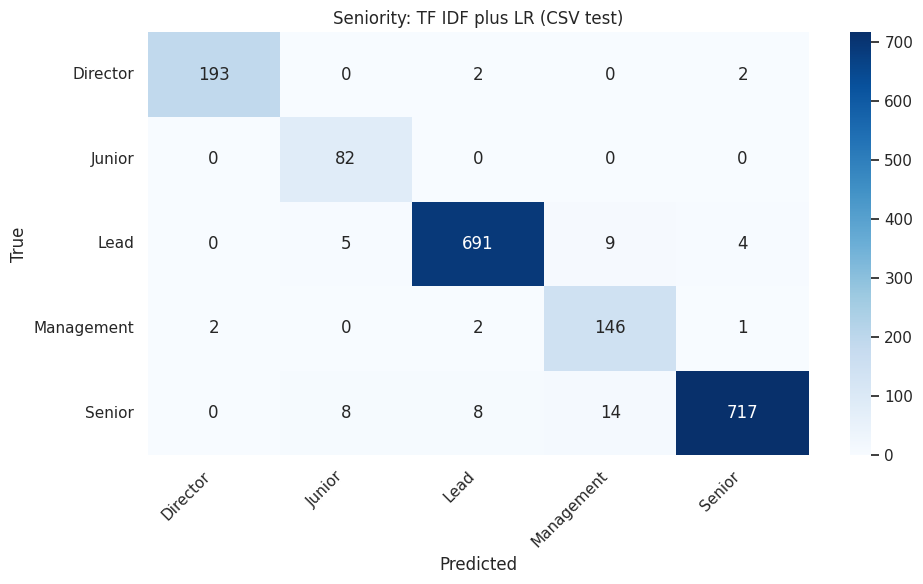

      true       pred  count
    Senior Management     14
      Lead Management      9
    Senior     Junior      8
    Senior       Lead      8
      Lead     Junior      5
      Lead     Senior      4
  Director       Lead      2
  Director     Senior      2
Management   Director      2
Management       Lead      2


In [99]:
cm = confusion_matrix(sen_y_true_csv, sen_pred_tfidf_csv, labels=sen_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sen_labels, yticklabels=sen_labels)
ax.set_title("Seniority: TF IDF plus LR (CSV test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(sen_labels):
    for j, p_lab in enumerate(sen_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

TF IDF plus Logistic Regression can capture strong seniority signals in job titles.
On the CSV test split this typically produces high precision and recall for levels with clear cues.
Most remaining mistakes are one level off, which is reflected by the confusion matrix concentrating around neighboring classes.


#### 7.2.4 Train TF IDF and Logistic Regression on full sen_df


In [100]:
sen_vectorizer_full = TfidfVectorizer(lowercase=True, min_df=2, ngram_range=(1, 2))
X_sen_full = sen_vectorizer_full.fit_transform(sen_df["text"])

sen_clf_full = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
_ = sen_clf_full.fit(X_sen_full, sen_df["label"])
print("sen_clf_full fitted")


sen_clf_full fitted


#### 7.2.5 JSON evaluation (strict)


In [101]:
X_sen_json = sen_vectorizer_full.transform(sen_eval_json_strict["text"])
sen_pred_tfidf_json = sen_clf_full.predict(X_sen_json)

sen_acc_tfidf_json = float(accuracy_score(sen_y_true_json, sen_pred_tfidf_json))
sen_macro_f1_tfidf_json = float(f1_score(sen_y_true_json, sen_pred_tfidf_json, average="macro"))

print({"n": int(len(sen_y_true_json)), "accuracy": sen_acc_tfidf_json, "macro_f1": sen_macro_f1_tfidf_json})

print(classification_report(sen_y_true_json, sen_pred_tfidf_json, zero_division=0))
report = classification_report(sen_y_true_json, sen_pred_tfidf_json, zero_division=0, output_dict=True)
df_report = pd.DataFrame(report).T
try:
    df_report = df_report.loc[sen_labels + ["accuracy", "macro avg", "weighted avg"]]
except Exception:
    pass
print(df_report.to_string())

{'n': 313, 'accuracy': 0.6900958466453674, 'macro_f1': 0.6342015842239087}
              precision    recall  f1-score   support

    Director       0.57      0.93      0.70        27
      Junior       0.50      0.44      0.47         9
        Lead       0.68      0.67      0.68       101
  Management       0.96      0.66      0.78       138
      Senior       0.42      0.74      0.54        38

    accuracy                           0.69       313
   macro avg       0.63      0.69      0.63       313
weighted avg       0.76      0.69      0.70       313

              precision    recall  f1-score     support
Director       0.568182  0.925926  0.704225   27.000000
Junior         0.500000  0.444444  0.470588    9.000000
Lead           0.680000  0.673267  0.676617  101.000000
Management     0.957895  0.659420  0.781116  138.000000
Senior         0.424242  0.736842  0.538462   38.000000
accuracy       0.690096  0.690096  0.690096    0.690096
macro avg      0.626064  0.687980  0.634202 

#### 7.2.6 Confusion matrix and dominant confusions


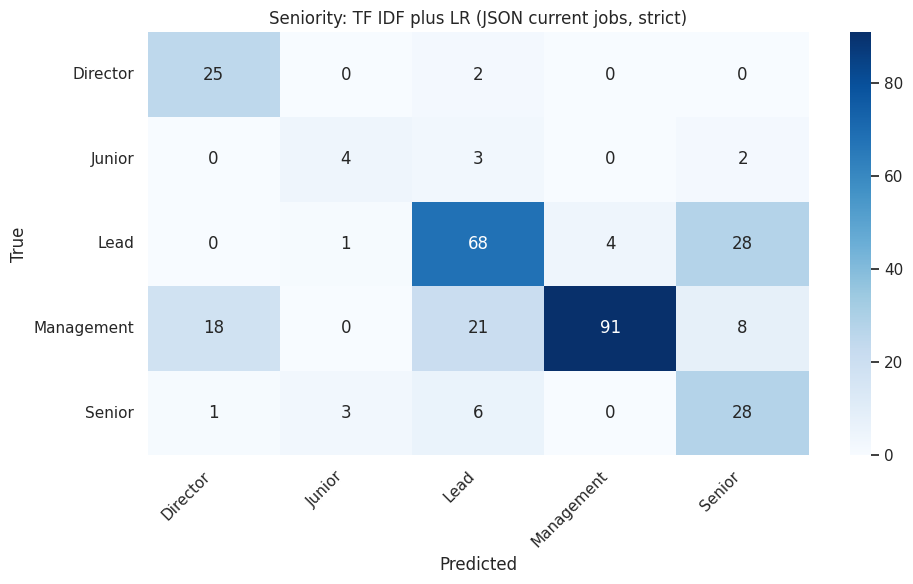

      true       pred  count
      Lead     Senior     28
Management       Lead     21
Management   Director     18
Management     Senior      8
    Senior       Lead      6
      Lead Management      4
    Senior     Junior      3
    Junior       Lead      3
  Director       Lead      2
    Junior     Senior      2


In [102]:
cm = confusion_matrix(sen_y_true_json, sen_pred_tfidf_json, labels=sen_labels)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=sen_labels, yticklabels=sen_labels)
ax.set_title("Seniority: TF IDF plus LR (JSON current jobs, strict)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, t_lab in enumerate(sen_labels):
    for j, p_lab in enumerate(sen_labels):
        if i == j:
            continue
        c = int(cm[i, j])
        if c > 0:
            pairs.append({"true": t_lab, "pred": p_lab, "count": c})

df_top = pd.DataFrame(pairs).sort_values("count", ascending=False).head(10)
print(df_top.to_string(index=False))

#### Interpretation

On JSON current jobs, Seniority performance drops compared to the CSV test split, but the pattern of errors stays similar.
Most mistakes remain between adjacent levels such as Lead and Senior or Management and Director.
This suggests that the model still picks up seniority cues, but the real world titles are less consistent and sometimes omit explicit indicators.


## 8. Summary table


In [103]:
results = []

results.append({"baseline": "rule_based", "task": "department_csv_test", "accuracy": dept_acc_rule_csv, "macro_f1": dept_macro_f1_rule_csv})
results.append({"baseline": "rule_based", "task": "department_json", "accuracy": dept_acc_rule_json, "macro_f1": dept_macro_f1_rule_json})
results.append({"baseline": "rule_based", "task": "seniority_csv_test", "accuracy": sen_acc_rule_csv, "macro_f1": sen_macro_f1_rule_csv})
results.append({"baseline": "rule_based", "task": "seniority_json_strict", "accuracy": sen_acc_rule_json, "macro_f1": sen_macro_f1_rule_json})

results.append({"baseline": "tfidf_lr", "task": "department_csv_test", "accuracy": dept_acc_tfidf_csv, "macro_f1": dept_macro_f1_tfidf_csv})
results.append({"baseline": "tfidf_lr", "task": "department_json", "accuracy": dept_acc_tfidf_json, "macro_f1": dept_macro_f1_tfidf_json})
results.append({"baseline": "tfidf_lr", "task": "seniority_csv_test", "accuracy": sen_acc_tfidf_csv, "macro_f1": sen_macro_f1_tfidf_csv})
results.append({"baseline": "tfidf_lr", "task": "seniority_json_strict", "accuracy": sen_acc_tfidf_json, "macro_f1": sen_macro_f1_tfidf_json})

df_results = pd.DataFrame(results)
print(df_results.sort_values(["task", "macro_f1"], ascending=[True, False]).reset_index(drop=True))

     baseline                   task  accuracy  macro_f1
0    tfidf_lr    department_csv_test  0.922622  0.822830
1  rule_based    department_csv_test  0.350419  0.259536
2    tfidf_lr        department_json  0.238494  0.356946
3  rule_based        department_json  0.142259  0.190880
4    tfidf_lr     seniority_csv_test  0.969777  0.955470
5  rule_based     seniority_csv_test  0.329799  0.323138
6    tfidf_lr  seniority_json_strict  0.690096  0.634202
7  rule_based  seniority_json_strict  0.396166  0.397050


## 9. Key findings

TF IDF plus Logistic Regression is the strongest baseline on the labeled CSV test splits.
The rule based approach is explainable, but it performs poorly when titles are short, generic, or ambiguous.

Department performance drops substantially from CSV test to JSON evaluation, which indicates distribution shift.
A frequent pattern is that titles labeled as Other are predicted as specific departments.

Seniority is generally easier than Department because seniority cues often appear directly in titles.
On JSON, seniority drops but stays more stable than Department.
Most seniority errors are between adjacent levels.

Strict seniority evaluation on JSON is necessary because the JSON contains labels that are not present in the training CSV label set.
